# Thai plate reader: 200 images the letter CNN never saw

The letter CNN (`thai_letter_cnn_plates.pt`) was trained on glyphs cut from **2,801 `final_data` images**. Its training
log reports 15,188 real glyphs, and all of them came from the *dev* half of the data (`md5(file name) % 2 == 0`).
This notebook takes **200 images from the other half**. None of them was used to train the CNN, to tune the reader,
or in any earlier evaluation. It reads each image with every method `thai_plate_reader.py` offers and scores only:

1. **Plate identification**: was a plate found, and was its top line cut exactly right?
2. **Sections identified**: how many of the plate's three sections (letters, number, province) were located,
   and how many each method reads right.
3. **Extraction accuracy**: letters, number and province, each compared exactly with `solution.csv`.

No project file is changed. The notebook only imports `thai_plate_reader` and writes to `heldout_eval/`.

## Summary

There are 200 held-out images and 20 configurations (10 letters methods × 2 field engines). The ranges are 95% intervals.

| | share | 95% interval |
|---|---|---|
| **plate found** | **94.5%** (189 plates) | 90–97% |
| plate found and top line cut exactly | 68.0% (136) | 61–74% |
| letters section located (glyph count right) | 78.0% | 72–83% |
| number section located (glyph count right) | 77.5% | 71–83% |
| province band found | 94.5% | 90–97% |

| | default: `easyocr+cnn`, paddle field | best configuration | worst configuration |
|---|---|---|---|
| **letters** | **69.5%** | 70.0% (`cnn`, EasyOCR field) | 31.0% (`tesseract`) |
| **number** | **72.5%** | 72.5% (paddle field) | 67.0% (EasyOCR field) |
| **province** | **53.5%** | 56.5% (EasyOCR field) | 53.5% (paddle field) |
| all 3 sections right | 44.0% | 45.0% (`cnn+paddle`, paddle field) | 22.5% (`tesseract`, EasyOCR field) |

* **Finding the plate and its sections does not depend on the method.** No OCR engine is used to locate them. The
  11 plates not found all failed the same way: *could not find the large characters of the top line*.
* **Most letter and number errors start with the segmentation.** The letters are not located correctly on 22% of
  the plates and the number on 22.5%, counting the 11 plates not found. On correctly cut sections, letters are
  88.5% right (`cnn`) and numbers 89% (paddle).
* **Letters.** Every method that includes the plate-trained CNN scores 66–70%. The other engines on their own are far behind:
  whole crop (`group`) 45.5%, EasyOCR 42.5%, PaddleOCR 35%, Tesseract 31%. Adding EasyOCR to the CNN (the default)
  changes 2 of 200 plates, one each way.
* **The CNN generalises to plates it never saw.** Trained with real dev-half glyphs it scores 69.5%, against 51.0%
  for the fonts-only CNN. It fixes 37 plates and breaks none (p < 0.001).
* **Number.** PaddleOCR beats EasyOCR, 72.5% against 67.0% (15 plates against 4, p = 0.02).
* **Province is the weakest field.** PaddleOCR gets 53.5% and EasyOCR 56.5%, which is not a real difference
  (14 plates against 20, p = 0.39). Wrong provinces are mostly short names (เลย, ตาก, น่าน). A faint or badly cropped
  band likely gives little evidence, and the name-scoring then favours short words.
* **No configuration is meaningfully better than the default.** The top seven are within 1 point on all 3
  sections right.
* **How sure.** With 200 images every share is uncertain by about ±7 points. The earlier notebook's 200 held-out
  images gave higher shares (letters 76.5%, number 80%, province 61.5%). Its 400-image check gave
  letters 74%, number 76%, province 54%. These results are a little below both. They are within about one standard
  error of the 400-image check, so the gap is what two samples of this size differ by.

## 1. Setup

In [1]:
import copy
import hashlib
import random
import re
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import thai_plate_reader as tpr

DATA_DIR = Path("/Users/tanut/Desktop/work/get_license_data/data/final_data")
OUT_DIR = Path("heldout_eval")
PRED_CSV = OUT_DIR / "predictions.csv"   # one row per image x method; delete it to read the images again
N_IMAGES, SEED = 200, 2026
RUN_CHECK = True                         # compare the shared-segmentation shortcut with read() (~1 min)

warnings.simplefilter("ignore")
pd.set_option("display.max_colwidth", 70)
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb", "savefig.facecolor": "#fcfcfb",
    "axes.spines.top": False, "axes.spines.right": False, "axes.edgecolor": "#c3c2b7",
    "axes.labelcolor": "#52514e", "xtick.color": "#52514e", "ytick.color": "#52514e",
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "font.size": 10, "figure.dpi": 110,
})
BLUE, ORANGE, INK, MUTED, GRID = "#2a78d6", "#eb6834", "#0b0b0b", "#52514e", "#e6e5e0"
RAMP = ["#86b6ef", "#3987e5", "#1c5cab", "#0d366b"]   # 0, 1, 2, 3 sections right (light -> dark)

## 2. The 200 images, and why the CNN never saw them

The CNN was retrained with `train_letter_cnn.py --real <glyph folder>`. The glyphs were exported by a script that only
read the dev half. Each glyph file is named after its source image (`plate_02769_L1.png`), so the list of training
images is exact. It is saved in `heldout_eval/cnn_training_images.txt`. Earlier development runs also scored about
half of the held-out images while choosing between reader variants. Those images are excluded as well
(`heldout_eval/previously_evaluated_images.txt`), so these 200 are fresh.

In [2]:
sol = pd.read_csv(DATA_DIR / "solution.csv", encoding="utf-8-sig", dtype=str, keep_default_na=False)
meta = pd.read_csv(DATA_DIR / "metadata.csv", encoding="utf-8-sig", dtype=str, keep_default_na=False)

def read_list(path):
    with open(path, encoding="utf-8") as fh:
        return {line.strip() for line in fh if line.strip() and not line.startswith("#")}

cnn_train = read_list(OUT_DIR / "cnn_training_images.txt")
seen_before = read_list(OUT_DIR / "previously_evaluated_images.txt")
sol["split"] = sol["image"].map(lambda f: ("dev", "test")[int(hashlib.md5(f.encode()).hexdigest(), 16) % 2])
test = set(sol.loc[sol["split"] == "test", "image"])

pool = sorted(test - cnn_train - seen_before)
images = sorted(random.Random(SEED).sample(pool, N_IMAGES))

assert not cnn_train & test, "a CNN training image is in the held-out half"
assert not set(images) & (cnn_train | seen_before)
pd.Series({
    "final_data images": len(sol),
    "CNN training images (all in the dev half)": len(cnn_train),
    "held-out half": len(test),
    "held-out, never scored before": len(pool),
    f"sampled (seed {SEED})": len(images),
    "sampled images that trained the CNN": len(set(images) & cnn_train),
}).to_frame("images")

,images
final_data images,6344
CNN training images (all in the dev half),2801
held-out half,3196
"held-out, never scored before",1478
sampled (seed 2026),200
sampled images that trained the CNN,0


In [3]:
# what kinds of plate the sample holds, against the whole data set
C = tpr.THAI_CONSONANTS
def plate_format(letters):
    if letters.isdigit():
        return "bus/truck (30-1234)"
    for name, pattern in (("1 consonant (red/old)", f"[{C}]"), ("2 consonants", f"[{C}]{{2}}"),
                          ("digit + consonants", f"[1-9][{C}]{{1,2}}"),
                          ("3 consonants (old motorcycle)", f"[{C}]{{3}}")):
        if re.fullmatch(pattern, letters):
            return name
    return "other"

sol["format"] = sol["letters"].map(plate_format)
in_sample = sol["image"].isin(images)
comp = pd.DataFrame({"in sample": sol[in_sample]["format"].value_counts(),
                     "share of sample": sol[in_sample]["format"].value_counts(normalize=True),
                     "share of final_data": sol["format"].value_counts(normalize=True)}).fillna(0)
comp["in sample"] = comp["in sample"].astype(int)
comp.sort_values("in sample", ascending=False).style.format("{:.1%}", subset=["share of sample", "share of final_data"])

,in sample,share of sample,share of final_data
format,,,
digit + consonants,76,38.0%,35.0%
2 consonants,68,34.0%,35.9%
bus/truck (30-1234),28,14.0%,11.7%
1 consonant (red/old),23,11.5%,15.0%
3 consonants (old motorcycle),5,2.5%,2.3%


## 3. The methods

A reading has two engine choices. The **letters engine** reads the letters (e.g. `1กข`), and the **field engine**
reads the number and the province. Every combination below is a configuration `ThaiPlateReader` supports:

| letters method | how the letters are read |
|---|---|
| `group` | the field engine reads the whole letters crop as one line |
| `easyocr` | EasyOCR, one glyph at a time |
| `cnn` | the small CNN trained on fonts **and real dev-half glyphs** (`thai_letter_cnn_plates.pt`, the default CNN) |
| `cnn_fonts` | the same CNN trained on **fonts only** (`thai_letter_cnn.pt`), which never saw a plate |
| `tesseract` | Tesseract 5 LSTM, Thai model, one glyph at a time |
| `paddle` | PaddleOCR's Thai recogniser, one glyph at a time |
| `a+b…` | weighted average of the engines' per-glyph probabilities (`ENGINE_WEIGHTS`) |

| field engine | reads |
|---|---|
| `paddle` (default) | number, province, the `group` letters, and the line check added to per-glyph letters |
| `easyocr` | the same, with EasyOCR's recogniser |

The reader's default is **`easyocr+cnn` letters with the `paddle` field engine**. In this code, finding the plate and
cutting it into sections uses **no OCR engine**. So plate identification and section location are the same for every
method; only the readings differ. Each image is therefore segmented once, and every method reads the same glyphs and
crops. As in `read()`, per-glyph methods fall back to `group` when the glyphs look merged or there are more than 3.

In [4]:
reader = tpr.ThaiPlateReader(letters_engine="cnn", field_engine="paddle")   # read() itself only needs the cheap CNN
for name in ("easyocr", "tesseract", "paddle"):
    reader.make_letters_engine(name)
cnn_fonts = tpr.CNNLetters(str(Path(tpr.__file__).parent / "thai_letter_cnn.pt"))   # fonts only
cnn_fonts.name = "cnn_fonts"
# the same loaded models, with EasyOCR as the field engine
FIELD_READERS = {"paddle": reader, "easyocr": copy.copy(reader)}
FIELD_READERS["easyocr"].field_engine = "easyocr"
BASE_ENGINES = {**{n: reader._engines[n] for n in ("easyocr", "cnn", "tesseract", "paddle")},
                "cnn_fonts": cnn_fonts}
LETTER_METHODS = ["group", "easyocr", "cnn", "cnn_fonts", "tesseract", "paddle", "easyocr+cnn",
                  "cnn+paddle", "easyocr+cnn+paddle", "easyocr+cnn+tesseract+paddle"]
DEFAULT = ("paddle", "easyocr+cnn")
COLS = ["image", "field_engine", "letters_method", "error", "layout", "n_letter_glyphs", "n_number_glyphs",
        "letters_mode", "letters_pred", "number_pred", "province_pred"]


class Cached:
    """A letters engine that hands back probabilities computed earlier."""
    def __init__(self, name, dists):
        self.name, self.dists = name, dists

    def predict(self, glyphs, allowed):
        return self.dists


def read_all_methods(image):
    """One image, every method: segment once, run each base letters engine once,
    build the ensembles from those probabilities, then read() each configuration's way."""
    try:
        res = reader.read(str(DATA_DIR / "images" / image), return_debug=True)
    except Exception as e:   # PlateNotFound, or an unreadable image
        return [dict(image=image, field_engine=f, letters_method=m, error=f"{type(e).__name__}: {e}")
                for f in FIELD_READERS for m in LETTER_METHODS]
    dbg = res.pop("_debug")
    glyphs, layout, crops = dbg["glyphs"], res["layout"], dbg["crops"]
    per_letter = res["letters_detail"]["mode"].startswith("per-letter")
    allowed = tpr.letter_allowed_sets(len(glyphs), layout)
    dists = {n: e.predict(glyphs, allowed) for n, e in BASE_ENGINES.items()} if per_letter else {}
    rows = []
    for fname, fr in FIELD_READERS.items():
        group = fr.read_code(crops["letters"], tpr.THAI_CONSONANTS + tpr.DIGITS, tpr.LAYOUTS[layout]["letters_re"])
        number = fr.read_code(crops["number"], tpr.DIGITS, tpr.NUMBER_RE)["text"]
        province = fr.read_province(crops["province"])["text"]
        for m in LETTER_METHODS:
            if m == "group" or not per_letter:
                letters, mode = group["text"], "whole crop"
            else:
                names = m.split("+")
                engines = [Cached(n, dists[n]) for n in names]
                engine = engines[0] if len(engines) == 1 else tpr.EnsembleLetters(
                    engines, [tpr.ENGINE_WEIGHTS[n] for n in names])
                letters = fr.read_letters(glyphs, engine=engine, layout=layout, line_crop=crops["letters"])["text"]
                mode = "per-letter"
            rows.append(dict(image=image, field_engine=fname, letters_method=m, error="", layout=layout,
                             n_letter_glyphs=dbg["seg"]["n_letter_glyphs"],
                             n_number_glyphs=dbg["seg"]["n_number_glyphs"], letters_mode=mode,
                             letters_pred=letters, number_pred=number, province_pred=province))
    return rows


# read the images (resumable: images already in PRED_CSV are skipped)
done = set(pd.read_csv(PRED_CSV, dtype=str, keep_default_na=False)["image"]) if PRED_CSV.exists() else set()
todo = [f for f in images if f not in done]
print(f"{len(images)} images, {len(images) - len(todo)} already read, {len(todo)} to read; "
      f"{len(FIELD_READERS) * len(LETTER_METHODS)} methods")
t0 = time.perf_counter()
for i, f in enumerate(todo, 1):
    pd.DataFrame(read_all_methods(f), columns=COLS).to_csv(PRED_CSV, mode="a", index=False,
                                                           header=not PRED_CSV.exists())
    if i % 25 == 0 or i == len(todo):
        rate = (time.perf_counter() - t0) / i
        print(f"  {i}/{len(todo)}  {rate:.1f} s/image, ~{rate * (len(todo) - i) / 60:.0f} min left", flush=True)
pred = pd.read_csv(PRED_CSV, dtype=str, keep_default_na=False)
pred = pred[pred["image"].isin(images)]
print(f"{pred['image'].nunique()} images x {pred.groupby(['field_engine', 'letters_method']).ngroups} methods")

200 images, 200 already read, 0 to read; 20 methods
200 images x 20 methods


**Is the shortcut faithful?** The library's own `ThaiPlateReader(letters_engine=..., field_engine=...).read()` is run on
a few images for four configurations. Its letters, number and province must equal the rows above.

In [5]:
if RUN_CHECK:
    p = pred.set_index(["image", "field_engine", "letters_method"])
    checked = mismatched = 0
    for fe, le in [("paddle", "easyocr+cnn"), ("paddle", "tesseract"), ("easyocr", "cnn"), ("easyocr", "group")]:
        lib = tpr.ThaiPlateReader(letters_engine=le, field_engine=fe)
        for f in images[:5]:
            try:
                r = lib.read(str(DATA_DIR / "images" / f))
                got = (r["letters"], r["number"], r["province"])
            except tpr.PlateNotFound:
                got = ("", "", "")
            row = p.loc[(f, fe, le)]
            checked += 1
            if got != (row["letters_pred"], row["number_pred"], row["province_pred"]):
                mismatched += 1
                print("MISMATCH", fe, le, f, got, tuple(row[["letters_pred", "number_pred", "province_pred"]]))
        del lib
    print(f"{checked} readings checked against read(), {mismatched} differ")

20 readings checked against read(), 0 differ


## 4. Scoring

Every comparison with `solution.csv` is exact. The ranges in brackets are 95% Wilson intervals. With 200 images a
share near 50% is uncertain by about ±7 points, and a share near 90% by about ±4.

* **plate found**: the reader returned a reading, with no `PlateNotFound`.
* **section located**: for letters and number, the reader cut exactly as many glyphs as the answer has characters.
  The province has no glyph count to check, so its band counts as located whenever the plate is found.
* **section read right**: the method's reading of that section equals the answer.

In [6]:
truth = sol.set_index("image").loc[images, ["letters", "numbers", "province", "format"]]
d = pred.merge(truth, left_on="image", right_index=True)
d["method"] = d["letters_method"] + " | " + d["field_engine"]
d["found"] = d["error"] == ""
d["letters_ok"] = d["letters_pred"] == d["letters"]
d["number_ok"] = d["number_pred"] == d["numbers"]
d["province_ok"] = d["province_pred"] == d["province"]
d["letters_located"] = d["found"] & (pd.to_numeric(d["n_letter_glyphs"], errors="coerce") == d["letters"].str.len())
d["number_located"] = d["found"] & (pd.to_numeric(d["n_number_glyphs"], errors="coerce") == d["numbers"].str.len())
d["province_located"] = d["found"]
d["top_line_exact"] = d["letters_located"] & d["number_located"]
d["sections_located"] = d[["letters_located", "number_located", "province_located"]].sum(axis=1)
d["sections_right"] = d[["letters_ok", "number_ok", "province_ok"]].sum(axis=1)
per_image = d[(d["field_engine"] == "paddle") & (d["letters_method"] == "group")]   # method-independent columns
N = len(per_image)

def wilson(k, n, z=1.96):
    if n == 0:
        return np.nan, np.nan
    p, den = k / n, 1 + z ** 2 / n
    c, h = (p + z ** 2 / (2 * n)) / den, z * np.sqrt(p * (1 - p) / n + z ** 2 / (4 * n ** 2)) / den
    return c - h, c + h

def rate(s):
    """boolean Series -> share and its 95% interval, e.g. '76.5% [70%-82%]'"""
    k, n = int(s.sum()), len(s)
    lo, hi = wilson(k, n)
    return f"{k / n:.1%} [{lo:.0%}-{hi:.0%}]" if n else "-"
print(f"{N} images scored")

200 images scored


## 5. Plate identification

The same for every method, because no OCR engine is involved in finding the plate.

In [7]:
ident = pd.DataFrame({
    "plates": [per_image["found"].sum(), per_image["top_line_exact"].sum()],
    "share [95% CI]": [rate(per_image["found"]), rate(per_image["top_line_exact"])],
}, index=["plate found", "plate found, top line cut exactly (letter and number glyph counts right)"])
ident

,plates,share [95% CI]
plate found,189,94.5% [90%-97%]
"plate found, top line cut exactly (letter and number glyph counts right)",136,68.0% [61%-74%]


In [8]:
# why plates were not found, and the layout chosen for the rest
reasons = per_image.loc[~per_image["found"], "error"].str.replace(r"^\w+: ", "", regex=True).value_counts()
display(reasons.to_frame("plates not found"))
per_image.loc[per_image["found"], "layout"].value_counts().to_frame("plates found, by layout read")

,plates not found
error,
could not find the large characters of the top line,11


,"plates found, by layout read"
layout,
car,160
motorcycle,29


In [9]:
# plate identification by plate format
g = per_image.groupby("format")
by_fmt = pd.DataFrame({"images": g.size(), "plate found": g["found"].mean(),
                       "top line cut exactly": g["top_line_exact"].mean()}).sort_values("images", ascending=False)
by_fmt.style.format("{:.1%}", subset=["plate found", "top line cut exactly"])

,images,plate found,top line cut exactly
format,,,
digit + consonants,76,90.8%,71.1%
2 consonants,68,97.1%,75.0%
bus/truck (30-1234),28,100.0%,64.3%
1 consonant (red/old),23,100.0%,52.2%
3 consonants (old motorcycle),5,60.0%,20.0%


## 6. Sections identified

### 6a. Sections located

Located means the reader found the section and cut it into the right number of glyphs. This happens before any
engine reads anything, so it is the same for every method.

In [10]:
located = pd.DataFrame({
    "plates": [per_image[c].sum() for c in ("letters_located", "number_located", "province_located")],
    "share [95% CI]": [rate(per_image[c]) for c in ("letters_located", "number_located", "province_located")],
}, index=["letters (glyph count right)", "number (glyph count right)", "province (band found)"])
display(located)
dist = per_image["sections_located"].value_counts().reindex([3, 2, 1, 0], fill_value=0)
pd.DataFrame({"plates": dist, "share": (dist / N).map("{:.1%}".format)}).rename_axis("sections located (of 3)")

,plates,share [95% CI]
letters (glyph count right),156,78.0% [72%-83%]
number (glyph count right),155,77.5% [71%-83%]
province (band found),189,94.5% [90%-97%]


,plates,share
sections located (of 3),,
3,136,68.0%
2,39,19.5%
1,14,7.0%
0,11,5.5%


### 6b. Sections read right, per method

For each method, the share of plates where 3, 2, 1 or 0 of the sections (letters, number, province) are read
exactly right.

In [11]:
order = (d.groupby("method")["sections_right"].mean().sort_values(ascending=False)).index
sec = (d.groupby("method")["sections_right"].value_counts(normalize=True).unstack(fill_value=0)
       .reindex(columns=[3, 2, 1, 0], fill_value=0).loc[order])
sec.columns = [f"{c} of 3 right" for c in sec.columns]
sec["mean sections right"] = d.groupby("method")["sections_right"].mean().loc[order]
default_name = f"{DEFAULT[1]} | {DEFAULT[0]}"
(sec.style.format("{:.1%}", subset=sec.columns[:4]).format("{:.2f}", subset=["mean sections right"])
 .background_gradient(cmap="Blues", subset=sec.columns[:4], vmin=0, vmax=1)
 .apply(lambda r: ["font-weight: bold" if r.name == default_name else "" for _ in r], axis=1))

,3 of 3 right,2 of 3 right,1 of 3 right,0 of 3 right,mean sections right
method,,,,,
cnn | paddle,44.5%,25.0%,12.0%,18.5%,1.96
easyocr+cnn | paddle,44.0%,26.0%,11.5%,18.5%,1.96
easyocr+cnn+tesseract+paddle | paddle,44.5%,24.0%,12.5%,19.0%,1.94
easyocr+cnn+paddle | paddle,44.5%,24.0%,12.5%,19.0%,1.94
cnn | easyocr,44.0%,25.0%,11.5%,19.5%,1.94
cnn+paddle | easyocr,44.0%,25.0%,11.5%,19.5%,1.94
cnn+paddle | paddle,45.0%,22.0%,14.0%,19.0%,1.93
easyocr+cnn | easyocr,40.5%,28.5%,11.5%,19.5%,1.90
easyocr+cnn+paddle | easyocr,40.5%,29.0%,10.5%,20.0%,1.90


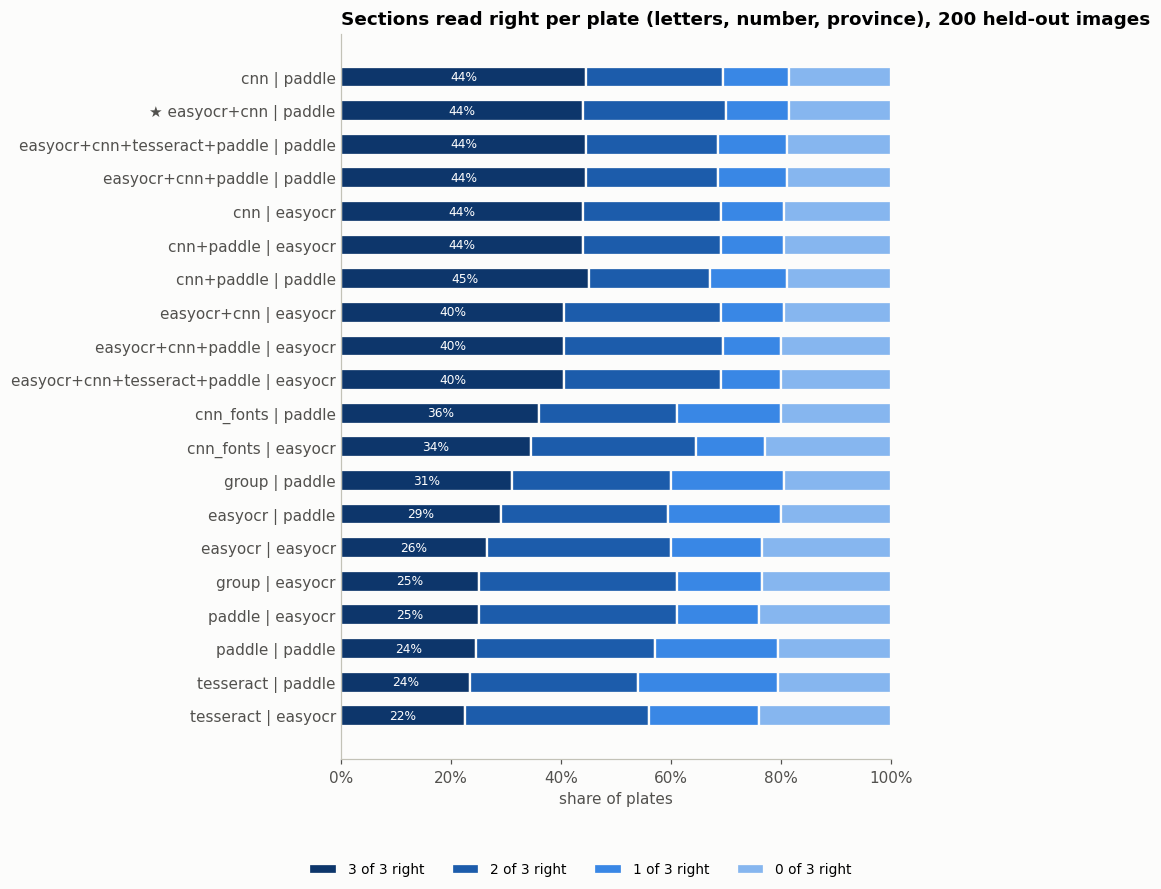

★ = the reader's default (easyocr+cnn letters, paddle field engine)


In [12]:
fig, ax = plt.subplots(figsize=(8.5, 0.34 * len(sec) + 1.3))
y = np.arange(len(sec))[::-1]
left = np.zeros(len(sec))
for k, colour in zip([3, 2, 1, 0], RAMP[::-1]):
    w = sec[f"{k} of 3 right"].values
    ax.barh(y, w, left=left, height=0.62, color=colour, edgecolor="#fcfcfb", linewidth=1.5,
            label=f"{k} of 3 right")
    left += w
for yi, v in zip(y, sec["3 of 3 right"].values):
    if v >= 0.08:   # only where the label fits inside the segment
        ax.text(v / 2, yi, f"{v:.0%}", va="center", ha="center", fontsize=8, color="white")
ax.set_yticks(y, [("★ " if m == default_name else "") + m for m in sec.index])
ax.set_xlim(0, 1)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.set_xlabel("share of plates")
ax.set_title(f"Sections read right per plate (letters, number, province), {N} held-out images")
fig.legend(*ax.get_legend_handles_labels(), loc="lower center", ncol=4, frameon=False, fontsize=9)
ax.tick_params(axis="y", length=0)
plt.tight_layout(rect=(0, 0.07, 1, 1)); plt.show()
print("★ = the reader's default (easyocr+cnn letters, paddle field engine)")

## 7. Extraction accuracy

### 7a. Number and province

These depend only on the field engine, because the letters engine is not involved. *If located* is the accuracy on
plates whose number was cut into the right number of digits. It separates the engine from the segmentation.

In [13]:
rows = {}
for fe in FIELD_READERS:
    x = d[(d["field_engine"] == fe) & (d["letters_method"] == "group")]
    rows[fe] = {"number": rate(x["number_ok"]),
                "number, if located": rate(x.loc[x["number_located"], "number_ok"]),
                "province": rate(x["province_ok"]),
                "province, if plate found": rate(x.loc[x["found"], "province_ok"])}
pd.DataFrame(rows).T.rename_axis("field engine")

,number,"number, if located",province,"province, if plate found"
field engine,,,,
paddle,72.5% [66%-78%],89.0% [83%-93%],53.5% [47%-60%],56.6% [49%-63%]
easyocr,67.0% [60%-73%],81.9% [75%-87%],56.5% [50%-63%],59.8% [53%-67%]


In [14]:
# when the province is wrong on a found plate (paddle field engine), what is read instead?
x = d[(d["field_engine"] == "paddle") & (d["letters_method"] == "group") & d["found"]]
wrong = x.loc[~x["province_ok"], "province_pred"]
print(f"{len(wrong)} wrong provinces out of {len(x)} plates found")
wrong.value_counts().head(8).to_frame("read instead (times)")

82 wrong provinces out of 189 plates found


,read instead (times)
province_pred,
เลย,28
ตาก,16
น่าน,11
ระนอง,6
ตราด,5
แพร่,3
ตรัง,3
สกลนคร,2


### 7b. Letters

Rows are the letters methods and columns the field engine. The field engine matters for `group` and, slightly, for
the per-glyph methods through the whole-crop line check. *If located* is again restricted to plates whose letters
were cut into the right number of glyphs.

In [15]:
lt = {}
for m in LETTER_METHODS:
    row = {}
    for fe in FIELD_READERS:
        x = d[(d["letters_method"] == m) & (d["field_engine"] == fe)]
        row[f"letters | {fe}"] = rate(x["letters_ok"])
        row[f"if located | {fe}"] = rate(x.loc[x["letters_located"], "letters_ok"])
    lt[m] = row
lt = pd.DataFrame(lt).T
acc = d.groupby(["letters_method", "field_engine"])["letters_ok"].mean().unstack()
lt = lt.loc[acc["paddle"].sort_values(ascending=False).index]
lt.rename_axis("letters method")

,letters | paddle,if located | paddle,letters | easyocr,if located | easyocr
letters method,,,,
cnn,69.5% [63%-75%],88.5% [82%-93%],70.0% [63%-76%],89.1% [83%-93%]
easyocr+cnn,69.5% [63%-75%],88.5% [82%-93%],66.5% [60%-73%],84.6% [78%-89%]
easyocr+cnn+paddle,68.0% [61%-74%],86.5% [80%-91%],66.5% [60%-73%],84.6% [78%-89%]
easyocr+cnn+tesseract+paddle,68.0% [61%-74%],86.5% [80%-91%],66.0% [59%-72%],84.0% [77%-89%]
cnn+paddle,67.0% [60%-73%],85.3% [79%-90%],70.0% [63%-76%],89.1% [83%-93%]
cnn_fonts,51.0% [44%-58%],64.7% [57%-72%],52.5% [46%-59%],66.7% [59%-74%]
group,45.5% [39%-52%],53.8% [46%-61%],39.0% [33%-46%],47.4% [40%-55%]
easyocr,42.5% [36%-49%],53.8% [46%-61%],39.5% [33%-46%],50.0% [42%-58%]
paddle,35.0% [29%-42%],44.2% [37%-52%],38.5% [32%-45%],48.7% [41%-56%]


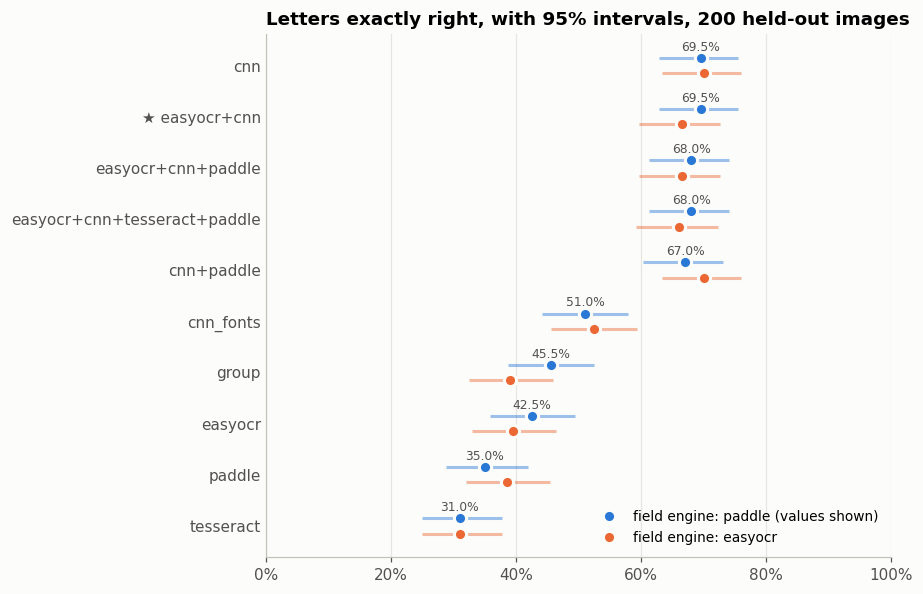

In [16]:
acc = acc.loc[lt.index[::-1]]
n = d.groupby(["letters_method", "field_engine"]).size().unstack().loc[acc.index]
fig, ax = plt.subplots(figsize=(8.5, 0.42 * len(acc) + 1.3))
y = np.arange(len(acc))
for fe, colour, dy in (("paddle", BLUE, 0.15), ("easyocr", ORANGE, -0.15)):
    p = acc[fe].values
    lo, hi = np.array([wilson(pi * ni, ni) for pi, ni in zip(p, n[fe].values)]).T
    ax.hlines(y + dy, lo, hi, color=colour, lw=2, alpha=0.45)
    ax.plot(p, y + dy, "o", ms=8, color=colour, mec="#fcfcfb", mew=2, label=f"field engine: {fe}" + (" (values shown)" if fe == "paddle" else ""))
for yi, v in zip(y, acc["paddle"].values):
    ax.text(v, yi + 0.36, f"{v:.1%}", ha="center", va="center", fontsize=8, color=MUTED)
ax.set_yticks(y, [("★ " if m == DEFAULT[1] else "") + m for m in acc.index])
ax.set_xlim(0, 1)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.grid(axis="x", color=GRID, lw=0.8); ax.set_axisbelow(True)
ax.tick_params(axis="y", length=0)
ax.set_title(f"Letters exactly right, with 95% intervals, {N} held-out images")
ax.legend(loc="lower right", frameon=False, fontsize=9)
plt.tight_layout(); plt.show()

### 7c. Which letters are misread

On plates whose letters were cut into the right number of glyphs, which characters does the default method get
wrong? Each row is one wrongly read glyph, counted by pair.

In [17]:
x = d[(d["field_engine"] == DEFAULT[0]) & (d["letters_method"] == DEFAULT[1]) & d["letters_located"]
      & (d["letters_pred"].str.len() == d["letters"].str.len())]
pairs = [(t, p) for tt, pp in zip(x["letters"], x["letters_pred"]) for t, p in zip(tt, pp) if t != p]
total = int(x["letters"].str.len().sum())
print(f"{DEFAULT[1]} | {DEFAULT[0]}: {len(pairs)} wrong letter glyphs out of {total} ({len(pairs) / max(1, total):.1%})")
conf = pd.Series([f"{t} → {p}" for t, p in pairs]).value_counts().head(12)
conf.to_frame("times (truth → read)")

easyocr+cnn | paddle: 22 wrong letter glyphs out of 351 (6.3%)


,times (truth → read)
ภ → ก,2
ฉ → ก,1
ช → ข,1
1 → 4,1
พ → ฬ,1
ฒ → ต,1
6 → 7,1
1 → 6,1
ช → ซ,1
0 → 1,1


## 8. All methods in one table

One row per configuration, ranked by the mean number of sections read right. Plate identification and section
location are the same in every row (section 5 and 6a). They are repeated so the table stands on its own.

In [18]:
g = d.groupby("method")
summary = pd.DataFrame({
    "plate found": g["found"].mean(),
    "top line cut exactly": g["top_line_exact"].mean(),
    "letters": g["letters_ok"].mean(),
    "number": g["number_ok"].mean(),
    "province": g["province_ok"].mean(),
    "all 3 right": g["sections_right"].apply(lambda s: (s == 3).mean()),
    "mean sections right (of 3)": g["sections_right"].mean(),
}).sort_values("mean sections right (of 3)", ascending=False)
pct = list(summary.columns[:6])
(summary.style.format("{:.1%}", subset=pct).format("{:.2f}", subset=["mean sections right (of 3)"])
 .background_gradient(cmap="Blues", subset=["letters", "number", "province"], vmin=0, vmax=1)
 .apply(lambda r: ["font-weight: bold" if r.name == default_name else "" for _ in r], axis=1))

,plate found,top line cut exactly,letters,number,province,all 3 right,mean sections right (of 3)
method,,,,,,,
cnn | paddle,94.5%,68.0%,69.5%,72.5%,53.5%,44.5%,1.96
easyocr+cnn | paddle,94.5%,68.0%,69.5%,72.5%,53.5%,44.0%,1.96
easyocr+cnn+tesseract+paddle | paddle,94.5%,68.0%,68.0%,72.5%,53.5%,44.5%,1.94
easyocr+cnn+paddle | paddle,94.5%,68.0%,68.0%,72.5%,53.5%,44.5%,1.94
cnn | easyocr,94.5%,68.0%,70.0%,67.0%,56.5%,44.0%,1.94
cnn+paddle | easyocr,94.5%,68.0%,70.0%,67.0%,56.5%,44.0%,1.94
cnn+paddle | paddle,94.5%,68.0%,67.0%,72.5%,53.5%,45.0%,1.93
easyocr+cnn | easyocr,94.5%,68.0%,66.5%,67.0%,56.5%,40.5%,1.90
easyocr+cnn+paddle | easyocr,94.5%,68.0%,66.5%,67.0%,56.5%,40.5%,1.90


### Are the differences real?

Every method read the same 200 plates, so two methods can be compared plate by plate. Only the plates where exactly
one of the two is right count. The p-value is an exact McNemar test; below about 0.05 the difference is unlikely to
be chance.

In [19]:
from math import comb

def mcnemar(a, b):
    """paired booleans -> (A right & B wrong, B right & A wrong, two-sided exact p)"""
    n10, n01 = int((a & ~b).sum()), int((~a & b).sum())
    k, n = min(n10, n01), n10 + n01
    return n10, n01, (min(1.0, 2 * sum(comb(n, i) for i in range(k + 1)) / 2 ** n) if n else 1.0)

d["all_right"] = d["sections_right"] == 3
piv = d.pivot_table(index="image", columns="method", aggfunc="first",
                    values=["letters_ok", "number_ok", "province_ok", "all_right"]).astype(bool)
best_all = summary["all 3 right"].idxmax()
COMPARE = [
    ("letters", "letters_ok", "cnn | paddle", "cnn_fonts | paddle"),     # does real-glyph training carry over?
    ("letters", "letters_ok", default_name, "cnn | paddle"),             # does EasyOCR add to the CNN?
    ("letters", "letters_ok", "cnn | paddle", "easyocr | paddle"),
    ("letters", "letters_ok", "cnn | paddle", "group | paddle"),
    ("number", "number_ok", "group | paddle", "group | easyocr"),         # field engines
    ("province", "province_ok", "group | paddle", "group | easyocr"),
    ("all 3 right", "all_right", default_name, best_all),
]
rows = []
for field, col, a, b in COMPARE:
    if a == b:
        continue
    n10, n01, p = mcnemar(piv[col][a], piv[col][b])
    rows.append({"field": field, "A": a, "B": b, "A share": piv[col][a].mean(), "B share": piv[col][b].mean(),
                 "A right, B wrong": n10, "B right, A wrong": n01, "p": p})
(pd.DataFrame(rows).style.format("{:.1%}", subset=["A share", "B share"]).format("{:.3g}", subset=["p"])
 .hide(axis="index"))

field,A,B,A share,B share,"A right, B wrong","B right, A wrong",p
letters,cnn | paddle,cnn_fonts | paddle,69.5%,51.0%,37,0,1.46e-11
letters,easyocr+cnn | paddle,cnn | paddle,69.5%,69.5%,1,1,1
letters,cnn | paddle,easyocr | paddle,69.5%,42.5%,55,1,1.58e-15
letters,cnn | paddle,group | paddle,69.5%,45.5%,56,8,5.56e-10
number,group | paddle,group | easyocr,72.5%,67.0%,15,4,0.0192
province,group | paddle,group | easyocr,53.5%,56.5%,14,20,0.392
all 3 right,easyocr+cnn | paddle,cnn+paddle | paddle,44.0%,45.0%,0,2,0.5
